### LIBRARY IMPORTS

In [23]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor
from src.gb_regressor import GBRegressor

### CONFIGURATION

In [2]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### CROSS-VALIDATION

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, kf, processor):
    mse_scores = []
    r2_scores = []
    oof_preds = np.zeros(len(data))

    for train_idx, valid_idx in kf.split(data):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        preds = model.predict(X_valid)
        oof_preds[valid_idx] = preds

        fold_mse = mean_squared_error(y_valid, preds)
        fold_r2 = r2_score(y_valid, preds)
        
        mse_scores.append(fold_mse)
        r2_scores.append(fold_r2)
    
    return mse_scores, r2_scores, oof_preds

### RIDGE REGRESSION

In [4]:
%%time

ridge = Ridge(alpha=1)
ridge_mse_scores, ridge_r2_scores, ridge_oof_preds = my_cross_validation(ridge, raw_train, target, kf, processor)

CPU times: total: 1.12 s
Wall time: 1.13 s


In [5]:
print("Ridge MSE scores:", ridge_mse_scores)
print("Ridge R2 scores:", ridge_r2_scores)

Ridge MSE scores: [0.01206151807514626, 0.012292627662309843, 0.012080486735903177, 0.01227748025803125, 0.012255805037537999]
Ridge R2 scores: [0.7801613291103521, 0.7780645197870598, 0.7791724013834471, 0.7769449852617083, 0.7756258485946159]


### DECISION TREE

In [6]:
%%time

dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_mse_scores, dt_r2_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, kf, processor)

CPU times: total: 2.17 s
Wall time: 2.17 s


In [7]:
print("Decision tree MSE scores:", dt_mse_scores)
print("Decision tree R2 scores:", dt_r2_scores)

Decision tree MSE scores: [0.01475656482446997, 0.014900155986629807, 0.014927312296510252, 0.015044994810785937, 0.014957945051626518]
Decision tree R2 scores: [0.7310401909861524, 0.7309872742440956, 0.7271333018030707, 0.7266652872797609, 0.7261561996582422]


### RANDOM FOREST

In [8]:
%%time

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_mse_scores, rf_r2_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, kf, processor)

CPU times: total: 1min 19s
Wall time: 1min 19s


In [9]:
print("Random forest MSE scores:", rf_mse_scores)
print("Random forest R2 scores:", rf_r2_scores)

Random forest MSE scores: [0.01345484685787404, 0.013653388767920006, 0.013612736103114557, 0.013778328456401139, 0.013597513180590597]
Random forest R2 scores: [0.754765890012322, 0.7534968538880396, 0.7511633521091817, 0.7496778498258078, 0.7510624172158482]


### NEURAL NETWORK

In [10]:
class MLP(NNRegressor):
    def __init__(self, **hyperparameters):
        super().__init__(**hyperparameters)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_valid: np.ndarray,
        y_valid: np.ndarray, 
        patience: int = 10
    ) -> None:
        
        input_size = X_train.shape[1]
        output_size = y_train.shape[1] if len(y_train.shape) > 1 else 1
        self._get_network(input_size, output_size)
        
        train_loader = self._prepare_loader(X_train, y_train)
        
        X_valid_t = torch.from_numpy(X_valid).to(torch.float32).to(self.device)
        y_valid_t = torch.from_numpy(y_valid).to(torch.float32).view(-1, output_size).to(self.device)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), self.learning_rate)
        
        best_loss = float('inf')
        best_model = None
        early_stop_count = 0

        for epoch in range(self.epochs):
            self.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                preds = self(batch_X)
                loss = criterion(preds, batch_y.view_as(preds))
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            self.eval()
            with torch.no_grad():
                val_preds = self(X_valid_t)
                val_loss = criterion(val_preds, y_valid_t).item()

                val_preds_np = val_preds.cpu().numpy().flatten()
                y_valid_np = y_valid_t.cpu().numpy().flatten()
                val_r2 = r2_score(y_valid_np, val_preds_np)

            if (epoch+1) % 10 == 0:
                print(f"Epoch: {epoch+1} | Validation MSE: {val_loss:.4f} | R^2: {val_r2:.4f}")

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(self.state_dict())
                early_stop_count = 0
            else:
                early_stop_count += 1

            if early_stop_count >= patience:
                print("-"*50)
                break
                
        if best_model:
            self.load_state_dict(best_model)

In [11]:
%%time

mlp = MLP(epochs=100, learning_rate=0.0001, hidden_size=[16, 8], batch_size=256)

mlp_mse_scores = []
mlp_r2_scores = []
mlp_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = mlp.predict(X_valid.values).ravel()
    mlp_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    mlp_mse_scores.append(fold_mse)
    mlp_r2_scores.append(fold_r2)

Epoch: 10 | Validation MSE: 0.0144 | R^2: 0.7371
Epoch: 20 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 30 | Validation MSE: 0.0121 | R^2: 0.7802
Epoch: 40 | Validation MSE: 0.0120 | R^2: 0.7805
Epoch: 50 | Validation MSE: 0.0120 | R^2: 0.7806
Epoch: 60 | Validation MSE: 0.0120 | R^2: 0.7806
--------------------------------------------------
Epoch: 10 | Validation MSE: 0.0124 | R^2: 0.7765
Epoch: 20 | Validation MSE: 0.0123 | R^2: 0.7775
Epoch: 30 | Validation MSE: 0.0123 | R^2: 0.7775
Epoch: 40 | Validation MSE: 0.0123 | R^2: 0.7774
--------------------------------------------------
Epoch: 10 | Validation MSE: 0.0122 | R^2: 0.7777
Epoch: 20 | Validation MSE: 0.0121 | R^2: 0.7784
Epoch: 30 | Validation MSE: 0.0121 | R^2: 0.7781
--------------------------------------------------
Epoch: 10 | Validation MSE: 0.0124 | R^2: 0.7753
Epoch: 20 | Validation MSE: 0.0123 | R^2: 0.7767
Epoch: 30 | Validation MSE: 0.0123 | R^2: 0.7762
--------------------------------------------------
Epoch: 10 | 

In [12]:
print("Neural network MSE scores:", mlp_mse_scores)
print("Neural network R2 scores:", mlp_r2_scores)

Neural network MSE scores: [0.01203551940490795, 0.012291569119302091, 0.012105049848334465, 0.012276832225319246, 0.012257476545124053]
Neural network R2 scores: [0.7806351926053515, 0.7780836310997267, 0.7787233952091653, 0.7769567586014401, 0.7755952473330063]


### GRADIENT BOOSTING (DTs)

In [13]:
%%time

gb_mse_scores = []
gb_r2_scores = []
gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=25,
        weak_learner_key="decision_tree",
        weak_learner_config={"max_depth": 8}
    )
    
    gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = gb.predict(X_valid.values).ravel()
    gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    gb_mse_scores.append(fold_mse)
    gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-21 19:20:29,660 - INFO - Iteration: 10 | Validation MSE: 0.026522 | Validation R^2: 0.516603 
2026-04-21 19:20:31,475 - INFO - Iteration: 20 | Validation MSE: 0.016521 | Validation R^2: 0.698888 
2026-04-21 19:20:33,265 - INFO - Iteration: 30 | Validation MSE: 0.013557 | Validation R^2: 0.752913 
2026-04-21 19:20:35,054 - INFO - Iteration: 40 | Validation MSE: 0.012620 | Validation R^2: 0.769975 
2026-04-21 19:20:37,063 - INFO - Iteration: 50 | Validation MSE: 0.012204 | Validation R^2: 0.777560 
2026-04-21 19:20:38,810 - INFO - Iteration: 60 | Validation MSE: 0.012077 | Validation R^2: 0.779872 
2026-04-21 19:20:40,623 - INFO - Iteration: 70 | Validation MSE: 0.012009 | Validation R^2: 0.781118 
2026-04-21 19:20:42,437 - INFO - Iteration: 80 | Validation MSE: 0.011988 | Validation R^2: 0.781495 
2026-04-21 19:20:44,386 - INFO - Iteration: 90 | Validation MSE: 0.011980 | Validation R^2: 0.781640 
2026-04-21 19:20:46,313 - INFO - Iteration: 100 | Validation MSE: 0.011979 | Valid

--------------------------------------------------


2026-04-21 19:20:53,600 - INFO - Iteration: 10 | Validation MSE: 0.025873 | Validation R^2: 0.532875 
2026-04-21 19:20:55,564 - INFO - Iteration: 20 | Validation MSE: 0.016460 | Validation R^2: 0.702826 
2026-04-21 19:20:57,340 - INFO - Iteration: 30 | Validation MSE: 0.013676 | Validation R^2: 0.753093 
2026-04-21 19:20:59,203 - INFO - Iteration: 40 | Validation MSE: 0.012705 | Validation R^2: 0.770625 
2026-04-21 19:21:01,124 - INFO - Iteration: 50 | Validation MSE: 0.012392 | Validation R^2: 0.776263 
2026-04-21 19:21:02,845 - INFO - Iteration: 60 | Validation MSE: 0.012271 | Validation R^2: 0.778455 
2026-04-21 19:21:04,619 - INFO - Iteration: 70 | Validation MSE: 0.012223 | Validation R^2: 0.779328 
2026-04-21 19:21:06,395 - INFO - Iteration: 80 | Validation MSE: 0.012196 | Validation R^2: 0.779818 
2026-04-21 19:21:08,285 - INFO - Iteration: 90 | Validation MSE: 0.012174 | Validation R^2: 0.780202 
2026-04-21 19:21:10,186 - INFO - Iteration: 100 | Validation MSE: 0.012176 | Valid

--------------------------------------------------


2026-04-21 19:21:19,323 - INFO - Iteration: 10 | Validation MSE: 0.025404 | Validation R^2: 0.535621 
2026-04-21 19:21:21,197 - INFO - Iteration: 20 | Validation MSE: 0.016599 | Validation R^2: 0.696582 
2026-04-21 19:21:23,074 - INFO - Iteration: 30 | Validation MSE: 0.013566 | Validation R^2: 0.752012 
2026-04-21 19:21:24,880 - INFO - Iteration: 40 | Validation MSE: 0.012543 | Validation R^2: 0.770721 
2026-04-21 19:21:26,690 - INFO - Iteration: 50 | Validation MSE: 0.012168 | Validation R^2: 0.777573 
2026-04-21 19:21:28,574 - INFO - Iteration: 60 | Validation MSE: 0.012025 | Validation R^2: 0.780181 
2026-04-21 19:21:30,349 - INFO - Iteration: 70 | Validation MSE: 0.011966 | Validation R^2: 0.781272 
2026-04-21 19:21:32,113 - INFO - Iteration: 80 | Validation MSE: 0.011945 | Validation R^2: 0.781640 
2026-04-21 19:21:33,955 - INFO - Iteration: 90 | Validation MSE: 0.011938 | Validation R^2: 0.781786 
2026-04-21 19:21:35,716 - INFO - Iteration: 100 | Validation MSE: 0.011939 | Valid

--------------------------------------------------


2026-04-21 19:21:42,302 - INFO - Iteration: 10 | Validation MSE: 0.024651 | Validation R^2: 0.552152 
2026-04-21 19:21:44,199 - INFO - Iteration: 20 | Validation MSE: 0.016395 | Validation R^2: 0.702139 
2026-04-21 19:21:46,104 - INFO - Iteration: 30 | Validation MSE: 0.013714 | Validation R^2: 0.750853 
2026-04-21 19:21:48,009 - INFO - Iteration: 40 | Validation MSE: 0.012727 | Validation R^2: 0.768786 
2026-04-21 19:21:49,846 - INFO - Iteration: 50 | Validation MSE: 0.012383 | Validation R^2: 0.775029 
2026-04-21 19:21:51,921 - INFO - Iteration: 60 | Validation MSE: 0.012226 | Validation R^2: 0.777873 
2026-04-21 19:21:53,851 - INFO - Iteration: 70 | Validation MSE: 0.012162 | Validation R^2: 0.779041 
2026-04-21 19:21:55,737 - INFO - Iteration: 80 | Validation MSE: 0.012130 | Validation R^2: 0.779621 
2026-04-21 19:21:57,727 - INFO - Iteration: 90 | Validation MSE: 0.012109 | Validation R^2: 0.780002 
2026-04-21 19:21:59,617 - INFO - Iteration: 100 | Validation MSE: 0.012096 | Valid

--------------------------------------------------


2026-04-21 19:22:10,670 - INFO - Iteration: 10 | Validation MSE: 0.027661 | Validation R^2: 0.493601 
2026-04-21 19:22:12,721 - INFO - Iteration: 20 | Validation MSE: 0.017303 | Validation R^2: 0.683226 
2026-04-21 19:22:14,464 - INFO - Iteration: 30 | Validation MSE: 0.014020 | Validation R^2: 0.743328 
2026-04-21 19:22:16,411 - INFO - Iteration: 40 | Validation MSE: 0.012786 | Validation R^2: 0.765912 
2026-04-21 19:22:18,375 - INFO - Iteration: 50 | Validation MSE: 0.012364 | Validation R^2: 0.773650 
2026-04-21 19:22:20,411 - INFO - Iteration: 60 | Validation MSE: 0.012212 | Validation R^2: 0.776430 
2026-04-21 19:22:22,196 - INFO - Iteration: 70 | Validation MSE: 0.012156 | Validation R^2: 0.777448 
2026-04-21 19:22:23,808 - INFO - Iteration: 80 | Validation MSE: 0.012140 | Validation R^2: 0.777755 
2026-04-21 19:22:25,669 - INFO - Iteration: 90 | Validation MSE: 0.012133 | Validation R^2: 0.777867 
2026-04-21 19:22:27,484 - INFO - Iteration: 100 | Validation MSE: 0.012135 | Valid

--------------------------------------------------
CPU times: total: 2min 4s
Wall time: 2min 3s


In [14]:
print("DT GB MSE scores:", gb_mse_scores)
print("DT GB R2 scores:", gb_r2_scores)

DT GB MSE scores: [0.011975881174067823, 0.01216934226394535, 0.011935677612166979, 0.012079623910167654, 0.012132515513665362]
DT GB R2 scores: [0.7817221859108724, 0.780290358301079, 0.7818194678263408, 0.7805396031850326, 0.7778829816194452]


### XGBOOST

In [15]:
%%time

xgb_mse_scores = []
xgb_r2_scores = []
xgb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=25
    )
    
    xgb.fit(X_train.values, y_train.values, eval_set=[(X_valid.values, y_valid.values)], verbose=False)

    preds = xgb.predict(X_valid.values).ravel()
    xgb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    xgb_mse_scores.append(fold_mse)
    xgb_r2_scores.append(fold_r2)
    
    print('-' * 50)

--------------------------------------------------
--------------------------------------------------
--------------------------------------------------
--------------------------------------------------
--------------------------------------------------
CPU times: total: 40.5 s
Wall time: 4.4 s


In [16]:
print("XGB MSE scores:", xgb_mse_scores)
print("XGB R2 scores:", xgb_r2_scores)

XGB MSE scores: [0.011917401186041834, 0.01218947803141914, 0.01194540561005056, 0.012101847909560159, 0.012116940771812005]
XGB R2 scores: [0.7827880685602353, 0.7799268199798579, 0.7816416430036378, 0.7801358416307189, 0.7781681174775958]


### GRADIENT BOOSTING (NNs)

In [17]:
%%time

nn_gb_mse_scores = []
nn_gb_r2_scores = []
nn_gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    nn_gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.5,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=0.5,
        early_stopping_rounds=10,
        weak_learner_key="neural_network",
        weak_learner_config={
            "epochs": 30,
            "learning_rate": 0.0001,
            "hidden_size": [16, 8],
            "batch_size": 256
        }
    )

    nn_gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = nn_gb.predict(X_valid.values).ravel()
    nn_gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    nn_gb_mse_scores.append(fold_mse)
    nn_gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-21 19:27:39,092 - INFO - Iteration: 10 | Validation MSE: 0.012071 | Validation R^2: 0.779983 
2026-04-21 19:32:38,042 - INFO - Iteration: 20 | Validation MSE: 0.012083 | Validation R^2: 0.779770 
2026-04-21 19:34:07,919 - INFO - Early stopping triggered at iteration 23. Best iteration: 13


--------------------------------------------------


2026-04-21 19:39:05,233 - INFO - Iteration: 10 | Validation MSE: 0.012297 | Validation R^2: 0.777984 
2026-04-21 19:44:02,837 - INFO - Iteration: 20 | Validation MSE: 0.012308 | Validation R^2: 0.777790 
2026-04-21 19:44:02,838 - INFO - Early stopping triggered at iteration 20. Best iteration: 10


--------------------------------------------------


2026-04-21 19:49:01,108 - INFO - Iteration: 10 | Validation MSE: 0.012075 | Validation R^2: 0.779280 
2026-04-21 19:54:02,022 - INFO - Iteration: 20 | Validation MSE: 0.012081 | Validation R^2: 0.779160 
2026-04-21 19:55:31,605 - INFO - Early stopping triggered at iteration 23. Best iteration: 13


--------------------------------------------------


2026-04-21 20:00:30,763 - INFO - Iteration: 10 | Validation MSE: 0.012277 | Validation R^2: 0.776962 
2026-04-21 20:05:30,793 - INFO - Iteration: 20 | Validation MSE: 0.012305 | Validation R^2: 0.776444 
2026-04-21 20:05:30,794 - INFO - Early stopping triggered at iteration 20. Best iteration: 10


--------------------------------------------------


2026-04-21 20:10:33,857 - INFO - Iteration: 10 | Validation MSE: 0.012242 | Validation R^2: 0.775886 
2026-04-21 20:15:32,629 - INFO - Iteration: 20 | Validation MSE: 0.012248 | Validation R^2: 0.775760 
2026-04-21 20:16:32,204 - INFO - Early stopping triggered at iteration 22. Best iteration: 12


--------------------------------------------------
CPU times: total: 1h 48min 22s
Wall time: 53min 56s


In [18]:
print("NN GB MSE scores:", nn_gb_mse_scores)
print("NN GB R2 scores:", nn_gb_r2_scores)

NN GB MSE scores: [0.012065700465347407, 0.01229711260160315, 0.012064941323855384, 0.012276522403743112, 0.01223978239398746]
NN GB R2 scores: [0.7800850989793491, 0.7779835470948796, 0.779456566755842, 0.7769623873831426, 0.7759191844496586]


### VISUALIZATION

C:\Users\oriol\AppData\Local\Temp\ipykernel_1572\3884412501.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


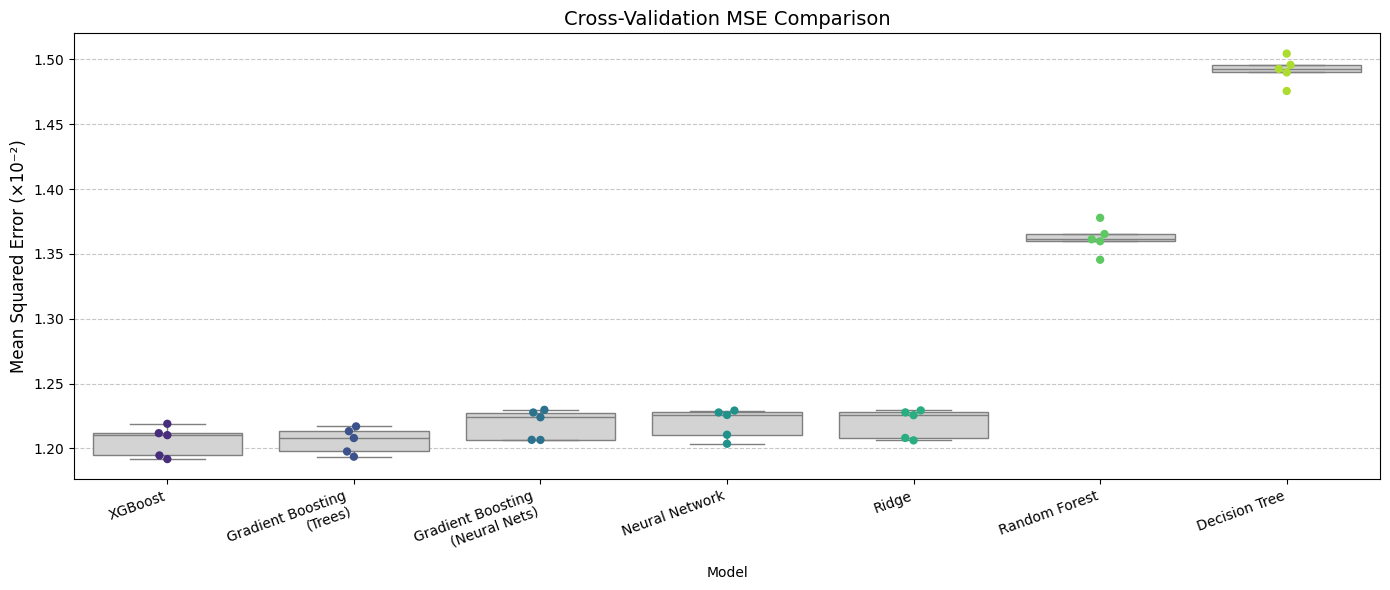

In [ ]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .mean()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_1572\2374248617.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


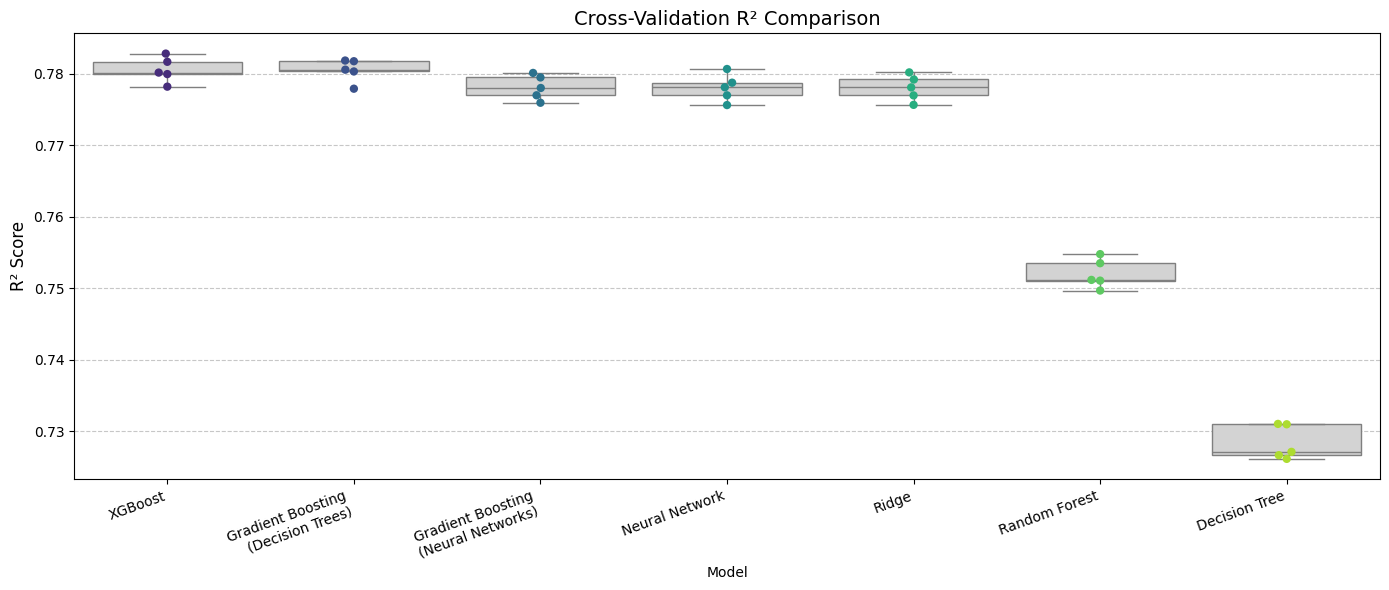

In [27]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Decision Tree': dt_r2_scores,
    'Random Forest': rf_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()